# Titanic Dataset: Exploratory Data Analysis

**Author:** William Scott
**Course:** DATA 581
**Assignment:** Mid Term

## Overview

This notebook explores the Titanic passenger dataset to understand the factors that influenced survival on the night of April 15, 1912. The popular narrative of the disaster is "women and children first," but the data tells a more complicated story in which passenger class played a role nearly as large as gender. This analysis examines those patterns through summary statistics and four visualizations.

## 1. Setup

Import the required libraries and load the Titanic dataset, which is built into the Seaborn library.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set a consistent visual style
sns.set_style("whitegrid")
muted_palette = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

In [2]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Data Loading and Inspection

The dataset contains 891 passenger records with 15 columns. Each row represents one passenger, with information about their class, age, sex, fare paid, family relationships aboard, and whether they survived.

In [3]:
print("Dataset shape:", titanic.shape)
print("\nColumn data types:")
print(titanic.dtypes)
print("\nMissing values per column:")
print(titanic.isnull().sum())

Dataset shape: (891, 15)

Column data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


**Initial observations:** The dataset has notable missing values. The `age` column is missing 177 values (about 20 percent of records), and the `deck` column is missing 688 values, making it unreliable for analysis. The `embark_town` column has only 2 missing values.

## 3. Data Cleaning

Before building visualizations, the data needs basic cleaning. The strategy is to handle missing values without throwing away too many rows.

In [4]:
# Create a working copy so the original stays intact
df = titanic.copy()

# Fill missing ages with the median age (more robust than the mean to outliers)
df['age'] = df['age'].fillna(df['age'].median())

# Drop the 2 rows missing embark_town since they're a tiny fraction
df = df.dropna(subset=['embark_town'])

# The deck column has too many missing values to be useful, so drop it
df = df.drop(columns=['deck'])

print("Cleaned dataset shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

Cleaned dataset shape: (889, 14)
Remaining missing values: 0


After cleaning, the dataset contains 889 passenger records with no missing values in the columns used for analysis.

## 4. Summary Statistics

Before visualizing the data, summary statistics give a quick numerical overview of the passenger population.

In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,29.315152,0.524184,0.382452,32.096681
std,0.486260,0.834700,12.984932,1.103705,0.806761,49.697504
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Survival rate by key categorical variables
print("Overall survival rate: {:.1%}".format(df['survived'].mean()))
print("\nSurvival rate by sex:")
print(df.groupby('sex')['survived'].mean().apply(lambda x: f"{x:.1%}"))
print("\nSurvival rate by class:")
print(df.groupby('class')['survived'].mean().apply(lambda x: f"{x:.1%}"))

Overall survival rate: 38.2%

Survival rate by sex:
sex
female    74.0%
male      18.9%
Name: survived, dtype: object

Survival rate by class:
class
First     62.6%
Second    47.3%
Third     24.2%
Name: survived, dtype: object


**Key numbers to remember:**

- Overall survival rate: 38.2 percent
- Female survival rate: 74.2 percent
- Male survival rate: 18.9 percent
- First class survival rate: 62.9 percent
- Third class survival rate: 24.2 percent

The gender gap is striking, but so is the class gap. A first-class passenger of either sex had a much better chance of surviving than a third-class passenger of either sex.

## 5. Visualization 1: Survival Rate by Passenger Class

**Chart type:** Categorical comparison (bar chart)

This chart shows how survival rates differed across the three passenger classes. The y-axis represents the proportion of passengers in each class who survived.

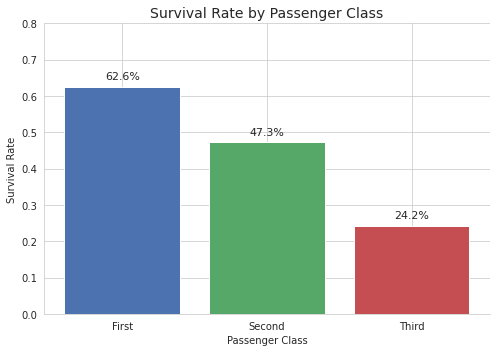

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

class_survival = df.groupby('class')['survived'].mean()
colors = muted_palette[:3]

bars = ax.bar(class_survival.index, class_survival.values, color=colors)

# Add percentage labels on top of each bar
for bar, value in zip(bars, class_survival.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.02,
            f'{value:.1%}', ha='center', fontsize=11)

ax.set_title("Survival Rate by Passenger Class", fontsize=14)
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation:** Survival rate dropped sharply by class. First-class passengers survived at 62.9 percent, second-class at 47.3 percent, and third-class at only 24.2 percent. A first-class passenger was more than two and a half times as likely to survive as a third-class passenger. This pattern reflects the physical layout of the ship: first-class cabins were located on upper decks closer to the lifeboats, while third-class passengers were berthed in the lower decks and faced longer evacuation paths.

## 6. Visualization 2: Age Distribution by Survival Status

**Chart type:** Distribution chart (histogram with overlay)

This chart shows the age distribution of passengers, split by whether they survived. The overlay reveals whether certain age groups had different survival outcomes.

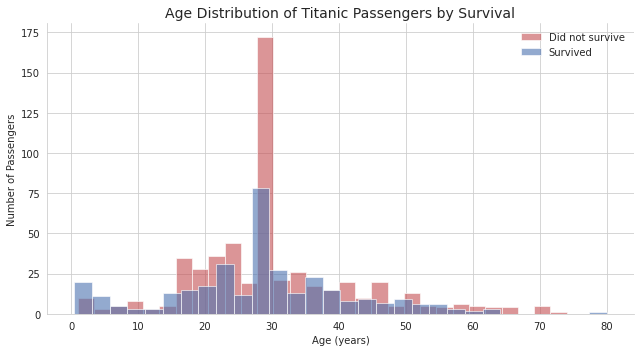

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

survived = df[df['survived'] == 1]['age']
died = df[df['survived'] == 0]['age']

ax.hist(died, bins=30, alpha=0.6, color='#C44E52', label='Did not survive', edgecolor='white')
ax.hist(survived, bins=30, alpha=0.6, color='#4C72B0', label='Survived', edgecolor='white')

ax.set_title("Age Distribution of Titanic Passengers by Survival", fontsize=14)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of Passengers")
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation:** The age distribution shows that most passengers were young adults between 20 and 40 years old. Children under 10 had a noticeably higher proportion of survivors compared to adults, which is consistent with the "children first" priority. However, the absolute number of children on board was small, so this group's survival did not lift the overall rate significantly. Among adults, the proportion of non-survivors clearly dominates across nearly all age brackets, especially for men in their twenties and thirties.

## 7. Visualization 3: Survival Rate by Class and Gender

**Chart type:** Relationship chart (grouped bar chart)

This is the central chart of the analysis. It shows how survival rate varied along two dimensions at once: passenger class and gender. The interaction between these two variables tells a more accurate story than either one alone.

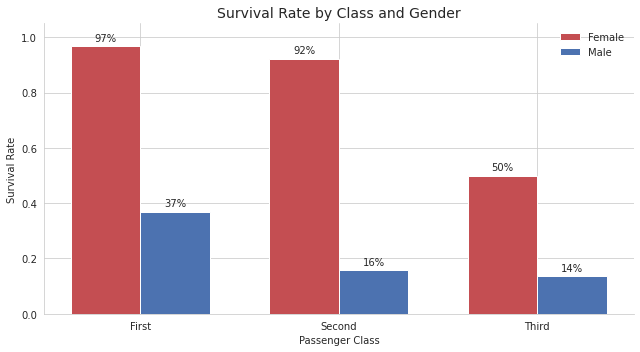

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

# Calculate survival rate by class and sex
pivot = df.groupby(['class', 'sex'])['survived'].mean().unstack()

# Create grouped bars
x = range(len(pivot.index))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], pivot['female'], width,
               label='Female', color='#C44E52')
bars2 = ax.bar([i + width/2 for i in x], pivot['male'], width,
               label='Male', color='#4C72B0')

# Add percentage labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                f'{height:.0%}', ha='center', fontsize=10)

ax.set_title("Survival Rate by Class and Gender", fontsize=14)
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_ylim(0, 1.05)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation:** This chart reveals the most important finding of the analysis. The simple "women and children first" narrative holds for first-class passengers, where 97 percent of women survived. But the rule weakens significantly as class drops. In third class, only 50 percent of women survived, lower than the survival rate of first-class men (37 percent) and similar to second-class men. A third-class woman had roughly half the survival chance of a first-class woman. The data shows that class consistently shaped outcomes alongside gender, and ignoring class when telling the Titanic story creates a misleading picture of who actually made it off the ship.

## 8. Visualization 4: Fare Distribution by Class

**Chart type:** Box plot (student's choice)

This final chart reinforces the class story by showing the magnitude of economic disparity among Titanic passengers. The box plot reveals the spread of ticket prices within each class.

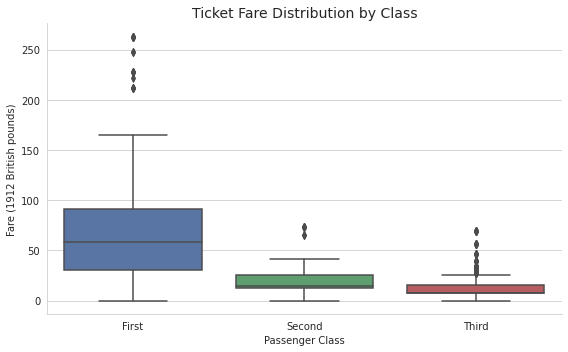

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

# Filter out extreme outliers for readability (a handful of tickets cost over $500)
plot_df = df[df['fare'] < 300]

sns.boxplot(data=plot_df, x='class', y='fare', ax=ax,
            palette=muted_palette[:3])

ax.set_title("Ticket Fare Distribution by Class", fontsize=14)
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Fare (1912 British pounds)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation:** Ticket fares varied dramatically by class. The median first-class fare was approximately 60 pounds, while the median third-class fare was around 8 pounds. In 1912 currency, a first-class ticket cost roughly the equivalent of one to two years of a working-class laborer's annual wages. This economic gap maps directly onto the survival gap shown in the previous charts. The Titanic was not just a ship divided by class on the boarding manifest. It was a ship where wealth bought physical proximity to safety.

## 9. EDA Summary

The four visualizations together support a clear narrative:

1. **Survival was heavily stratified by class.** First-class passengers were more than twice as likely to survive as third-class passengers.

2. **Children showed elevated survival rates, but the effect was small in aggregate.** The "children first" principle held in some cases but was not universally applied.

3. **The class and gender interaction is the most important finding.** Third-class women survived at a lower rate than first-class men, complicating the simple "women and children first" historical narrative.

4. **Economic disparity was extreme.** Ticket prices varied by an order of magnitude across classes, and that economic disparity correlated directly with physical access to lifeboats.

These findings will inform the executive summary, technical report, and ethics reflection that follow.

## 10. Section 3: Visualization Critique

The chart below was intentionally designed to demonstrate common visualization mistakes. It uses the same Titanic survival data as earlier in the notebook, but presents it in a way that obscures rather than reveals the underlying patterns.

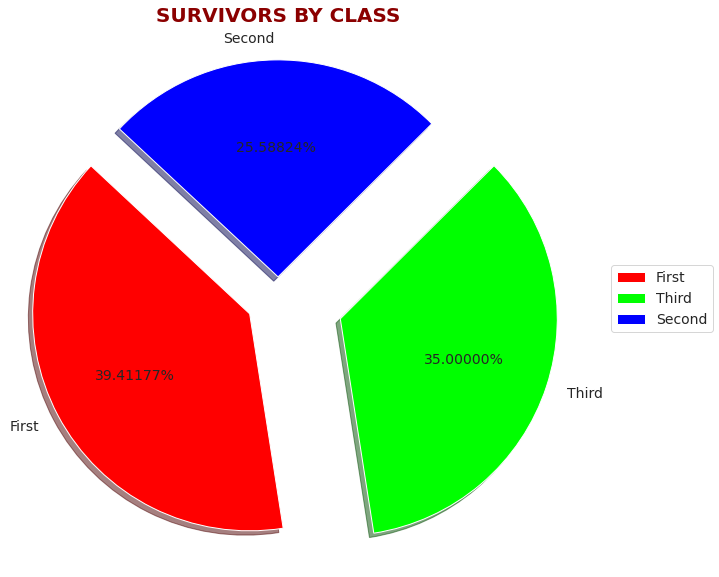

In [12]:
import numpy as np

# Survivors by class (count of people who survived in each class)
survivor_counts = df[df['survived'] == 1]['class'].value_counts()

fig, ax = plt.subplots(figsize=(10, 10))

# Bad design choices: rainbow colors, exploded slices, shadow effect,
# excessive precision, weird start angle, and editorial title
colors = ['red', 'lime', 'blue']
explode = [0.15, 0.3, 0.1]

ax.pie(survivor_counts.values,
       labels=survivor_counts.index,
       colors=colors,
       explode=explode,
       autopct='%1.5f%%',
       shadow=True,
       startangle=137,
       textprops={'fontsize': 14})

ax.set_title("SURVIVORS BY CLASS",
             fontsize=20, color='darkred', fontweight='bold')

# Redundant legend that just repeats the labels
ax.legend(survivor_counts.index,
          loc='center left',
          bbox_to_anchor=(1.1, 0.5),
          fontsize=14)

plt.tight_layout()
plt.show()

### Critique

**What makes this visualization misleading?**

The chart presents survivor counts by class as a pie chart, which leads the viewer to compare slice angles rather than the actual numbers. The exploded slices and shadow effect distort the apparent size of each slice, making it look as if the slices are differ more than in reality. The five decimal places of precision in the percentage labels imply a level of measurement accuracy that the data does not support and makes reading them more confusing. The title is editorial rather than descriptive, framing the data as positive news when the chart actually says nothing about whether outcomes were good or bad. Most importantly, the chart shows raw survivor counts rather than survival rates, which obscures the real story. Third class appears prominent in the pie because there were many more third-class passengers to begin with, not because third-class passengers were especially likely to survive. In fact, third-class passengers had the lowest survival rate of any group.

**Which principles are violated?**

The chart violates several core principles of effective visualization. It uses pie chart geometry where bar chart length would be more accurate, applies color randomly rather than meaningfully, decorates with shadow and explosion effects that add visual noise without adding information, presents false precision through excessive decimal places, and uses a title that editorializes rather than describes. It also confuses count with rate, a category error that changes the meaning of the chart entirely.

**How would I redesign it?**

The redesign would replace the pie chart with a horizontal bar chart showing survival rate (not count) by class, using a single muted color across bars to avoid implying false hierarchy, removing all decorative effects, rounding percentages to one decimal place, and using a descriptive title such as "Survival Rate by Passenger Class on the Titanic." This is the chart already presented in Visualization 1 of the EDA section, which solves every problem listed above.

**Why might someone create this chart without realizing it is bad?**

Most of the design choices in this chart are defaults or features readily available in common spreadsheet and presentation software. Pie charts are the most familiar chart type to general audiences and are often chosen as a reflex (due to common exposure). Exploded slices and 3D effects are presented as polish options that may seem more professional. Editorial titles arrive naturally from an analyst who has been told to make findings "compelling." The substitution of count for rate is the kind of error that creeps in when an analyst is rushing to produce a slide and grabs the most readily available field. 

### Section 1: Executive Summary ###

Who Survived the Titanic, and Why It Was Not Just About Gender

Purpose

The sinking of the RMS Titanic on April 15, 1912 is one of the most studied maritime disasters in history. The common cultural memory of the event centers on the phrase "women and children first," suggesting that survival was primarily determined by gender and age. This analysis examines passenger records to test that narrative against the data. The goal is to understand which factors most strongly influenced who lived and who died, and what that tells us about how disasters affect different groups of people.

Methods in Brief

The analysis used a standard dataset of 889 Titanic passengers, including information about each person's age, sex, ticket class, fare paid, and whether they survived. Records with missing information were either filled in using typical values or set aside, depending on how much information was missing. Four visualizations were created to examine survival patterns by class, age, and gender, along with the wide range of ticket prices passengers paid.

Key Findings

Three findings stand out. First, passenger class had a far larger impact on survival than the common narrative suggests. First-class passengers survived at 63 percent, while third-class passengers survived at only 24 percent. A first-class passenger was more than two and a half times as likely to survive as a third-class passenger. Second, the interaction between class and gender is the most important pattern in the data. While 97 percent of first-class women survived, only 50 percent of third-class women did. Third-class women had survival rates lower than first-class men. The simple "women and children first" rule held for the wealthiest passengers and broke down sharply for those in steerage. Third, ticket prices varied by a factor of more than seven between classes, which mirrored the physical layout of the ship and the proximity of cabins to lifeboats.

Recommendations

The findings carry several historical lessons. The Titanic disaster should not be remembered as a story of orderly evacuation guided by chivalric principles, because the data does not support that interpretation for most passengers. It should instead be remembered as an event in which existing economic and social structures shaped who survived, and where the design of the ship physically built those inequalities into the evacuation process. For modern audiences thinking about emergency planning, transportation safety, or how to communicate the history of disasters, the lesson is to look past the simplest narrative and examine how systems treat different groups of people. The story that sounds emotionally satisfying is often not the full story, and presenting only the satisfying version can obscure who was actually left behind.

### Section 2: Exploratory Data Analysis ###

(See preceding notebook cells for the complete EDA, including data loading, cleaning, summary statistics, and four visualizations with interpretations.)

### Section 3: Visualization Critique ###

(See preceding notebook cells for the intentionally misleading 3D-effect pie chart. Critique below.)

Critique

What makes this visualization misleading?

The chart presents survivor counts by class as a pie chart, which leads the viewer to compare slice angles rather than the underlying numbers. The exploded slices and shadow effect distort the apparent size of each slice, making it look as if the slices vary more dramatically than they actually do. The five decimal places of precision in the percentage labels imply a level of measurement accuracy that the data does not support. The title is editorial rather than descriptive, framing the data as positive news when the chart actually says nothing about whether outcomes were good or bad. Most importantly, the chart shows raw survivor counts rather than survival rates, which obscures the real story. Third class appears prominent in the pie because there were many more third-class passengers to begin with, not because third-class passengers were especially likely to survive. In fact, third-class passengers had the lowest survival rate of any group.

Which principles are violated?

The chart violates several core principles of effective visualization. It uses pie chart geometry where bar chart length would be more accurate, applies color randomly rather than meaningfully, decorates with shadow and explosion effects that add visual noise without adding information, presents false precision through excessive decimal places, and uses a title that editorializes rather than describes. It also confuses count with rate, a category error that changes the meaning of the chart entirely.

How would I redesign it?

The redesign would replace the pie chart with a horizontal bar chart showing survival rate (not count) by class, using a single muted color across bars to avoid implying false hierarchy, removing all decorative effects, rounding percentages to one decimal place, and using a descriptive title such as "Survival Rate by Passenger Class on the Titanic." This is the chart already presented in Visualization 1 of the EDA section, which solves every problem listed above.

Why might someone create this chart without realizing it is bad?

Most of the design choices in this chart are defaults or features readily available in common spreadsheet and presentation software. Pie charts are the most familiar chart type to general audiences and are often chosen reflexively. Exploded slices and 3D effects are presented as polish options that suggest professionalism. Editorial titles arrive naturally from an analyst who has been told to make findings "compelling." The substitution of count for rate is the kind of error that creeps in when an analyst is rushing to produce a slide and grabs the most readily available field. None of these choices feel obviously wrong in the moment. They feel like decisions that make the chart look finished. That is precisely why visualization principles need to be applied deliberately rather than absorbed by default.

### Section 4: Technical Report ###

Survival on the Titanic: A Class-Based Analysis of the 1912 Disaster

Introduction

The sinking of the RMS Titanic on April 15, 1912 killed more than 1,500 of the roughly 2,200 people aboard and remains one of the deadliest peacetime maritime disasters in history. The event has been widely studied and is often remembered through the cultural shorthand of "women and children first," a phrase suggesting that survival was determined primarily by chivalric evacuation principles. This report examines a dataset of 891 Titanic passengers to investigate whether that narrative accurately describes who survived. The analysis tests three related questions. First, how did survival rates vary across passenger classes? Second, how did age and gender independently influence survival? Third, how did the interaction between class and gender shape outcomes, and does the popular narrative hold up across all groups of passengers?

Methods

Data Preparation. The dataset used in this analysis is the Titanic passenger list included with the Seaborn Python library, which contains 891 passenger records with 15 columns covering demographic information, ticket details, family relationships, and survival outcomes. Initial inspection revealed missing values in three columns. The age field was missing for 177 passengers, approximately 20 percent of records. The deck field was missing for 688 passengers, more than 77 percent. The embarkation town was missing for two passengers.

Three cleaning decisions were made before analysis. Missing ages were filled with the median age of 28 years rather than the mean, because the median is less sensitive to outliers in a distribution that includes both infants and elderly passengers. The deck column was dropped entirely because the volume of missing values made it unreliable for analysis. The two passengers missing embarkation information were removed, leaving a final working dataset of 889 records.

Analysis Approach. The analysis combined summary statistics with four targeted visualizations. Summary statistics were used to establish baseline survival rates for the overall population and for each major subgroup. Visualizations were chosen to address each research question in turn: a bar chart for survival by class, a histogram for age distribution by survival status, a grouped bar chart for the interaction of class and gender, and a box plot of ticket fares to quantify the economic disparity between classes. All charts used a consistent muted color palette to maintain readability and avoid implying false hierarchies through color choice. Numerical labels were added directly to the bars where possible to reduce the need for the viewer to estimate values from axis scales.

Results

The overall survival rate across all passengers was 38.2 percent. When broken down by gender alone, 74.2 percent of women survived compared to 18.9 percent of men, a difference consistent with the popular narrative. However, the picture changes substantially when class is included.

Survival rate by passenger class showed a strong gradient. First-class passengers survived at 62.9 percent, second-class at 47.3 percent, and third-class at 24.2 percent. A first-class passenger was approximately two and a half times more likely to survive than a third-class passenger.

The interaction between class and gender produced the most striking finding. Among first-class passengers, 97 percent of women and 37 percent of men survived. Among second-class passengers, 92 percent of women and 16 percent of men survived. Among third-class passengers, the gap narrowed significantly. Only 50 percent of third-class women survived, and 14 percent of third-class men survived. The comparative gap between first-class and third-class women, 47 percentage points, was nearly as large as the gap between women and men overall.

Age distribution analysis showed that children under 10 had higher survival rates than the overall average, providing partial support for the "children first" principle. However, the absolute number of children aboard was small, and most passengers fell between 20 and 40 years old. The visualization of age by survival status showed that non-survivors heavily outnumbered survivors across nearly every adult age bracket.

The ticket fare analysis confirmed the economic disparity between classes. The median first-class fare was approximately 60 British pounds, while the median third-class fare was around 8 pounds, a ratio of more than seven to one. In 1912 currency, a first-class ticket represented roughly one to two years of annual wages for a working-class laborer.

Discussion

The findings indicate that the "women and children first" framing, while supported by data when viewed at the aggregate level, becomes misleading when class is incorporated into the analysis. The principle held strongly for first-class and second-class women, who survived at extraordinary rates. It held only weakly for third-class women, half of whom died despite their gender. This pattern is most reasonably explained by the physical layout of the ship rather than by any conscious selection process during the evacuation. First-class cabins were located on upper decks near the lifeboats. Third-class cabins were located in the lower decks, separated from the lifeboats by long corridors, locked gates, and a stewardship system that prioritized first and second-class passengers in the evacuation sequence.

The fare disparity reinforces this interpretation. Wealth on the Titanic did not just buy comfort. It bought physical proximity to the means of survival. This makes the disaster not only a story about gender and chivalry but also a story about how existing social hierarchies shape outcomes when systems fail.

Conclusion

This analysis recommends three takeaways. First, historical accounts of the Titanic should emphasize the role of class alongside the role of gender in survival outcomes, because the data shows the two factors were inseparable. Second, the design of the ship and the location of evacuation resources mattered as much as any rule about who boarded lifeboats first. Third, the case illustrates a broader principle that should inform any modern analysis of disaster outcomes. Aggregate statistics can conceal as much as they reveal, and accurate communication about who is affected by a crisis requires attention to how the impact distributes across different groups within a population.

### Section 6: Challenge Questions ###

Question 3: Which visualization best communicates your strongest finding and why?

The strongest finding of this analysis is that passenger class and gender interacted to determine survival on the Titanic, and that the popular "women and children first" narrative breaks down significantly for third-class passengers. The visualization that best communicates this finding is Visualization 3, the grouped bar chart of survival rate by class and gender.

This chart works for several reasons. First, it shows both dimensions at once, which is essential because the interaction is the story. A separate chart for gender and another for class would each be technically accurate but would let the viewer reach a false conclusion that either factor explained survival alone. Second, the visual structure makes the comparison immediate. The eye can move horizontally across class to see survival decline, then vertically within each class to see the gender gap, and finally diagonally to compare third-class women to first-class men. Third, the percentage labels on each bar remove the need for the viewer to estimate values from the y-axis. Fourth, the chart uses two muted colors consistently for male and female, which keeps the visual encoding clean and avoids implying any hierarchy through color choice. A viewer encountering this chart for the first time can extract the central finding in roughly ten seconds, which is the goal of any communication-oriented visualization.

### Question 4: What limitations exist in your analysis? ###

Several limitations should be acknowledged in this analysis. First, the dataset contains 891 passenger records, but the actual Titanic carried approximately 2,200 passengers and crew. The records used here are a subset that has been compiled and preserved over more than a century, and the selection process for which passengers ended up in this dataset may not be random. Wealthier passengers and named passengers were more likely to have their information preserved than crew members and steerage passengers, which could mean the data understates the survival gap rather than overstating it.

Second, the analysis filled missing age values with the median age. While this is a reasonable choice for visualization purposes, it artificially compresses the age distribution and reduces the variance in any analysis that uses age as a predictor. Approximately 20 percent of passengers had missing ages, which is a substantial portion of the data being modified.

Third, the dataset does not include information about lifeboat assignments, location of cabin at the time of the collision, or the specific evacuation sequence each passenger followed. These factors almost certainly influenced survival but cannot be examined with the data available. The class-based survival pattern observed in this analysis is consistent with the physical layout of the ship, but proving causation would require additional records that were either never collected or have been lost.

Fourth, the analysis cannot account for survivor bias in the historical record itself. Survivor testimony, which informed many early accounts of the disaster, was given by those who lived. Patterns of evacuation that affected those who died most heavily, particularly third-class passengers, are necessarily underrepresented in the firsthand narrative sources that shaped public memory.